<a href="https://colab.research.google.com/github/stephentangzizhong/Neuroinformatics-Workshop-Code/blob/main/2_Rate_coding_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# download the class data and library

!git clone https://github.com/kdharris101/NeuralCodingClass.git

Cloning into 'NeuralCodingClass'...
remote: Enumerating objects: 295, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 295 (delta 1), reused 18 (delta 1), pack-reused 277 (from 1)
Receiving objects: 100% (295/295), 391.36 MiB | 20.45 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Updating files: 100% (268/268), done.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

import NeuralCodingClass.neurocode as nc

In [ ]:
# load the data
FileDir = r'NeuralCodingClass/data/bush'
Experiment = 'Patient2Session3'

spikes=nc.load_object(os.path.join(FileDir, Experiment, 'spikes'))
stims=nc.load_object(os.path.join(FileDir, Experiment, 'stims'))
stims.frames = stims.frames.astype(int) # correct datatype
spikes.clusters = spikes.clusters.astype(int) # correct datatype


In [ ]:
# we have loaded two data objects as a "Bunch", a simple datastructure which
# contains many arrays, all with the same number of rows.

# spikes has one row per spike
# stims has one row per stimulus.

# let's see what's in it:

for k in spikes.keys():
  print(f'spikes.{k:<20}: size {spikes[k].shape}\t dtype {spikes[k].dtype}')

for k in stims.keys():
  print(f'stims.{k:<20}: size {stims[k].shape}\t dtype {stims[k].dtype}')



spikes.clusters            : size (30638,)	 dtype int64
spikes.times               : size (30638,)	 dtype float64
stims.intervals           : size (300, 2)	 dtype float64
stims.frames              : size (300,)	 dtype int64


**Here's what the arrays contain:**

spikes.times: time of each spike (seconds)

spikes.clusters: neuron assignment of each spike (int)

stims.intervals: start and stop time of each stimulus trial (seconds)

stims.frames: which stimulus was shown on each trial (int)

In [ ]:
# now we are going to count how many spikes each neuron fired following each
# stimulus presentation. This uses one function from the neurocode library
# (made for this class), and one from numpy.
#
# nc.find_close_pairs finds all spike-stimulus pairs for which the spike is at
# most 1s after the stimulus.
#
# np.histogram2d is built in to numpy and makes a 2d array counting the spikes of
# each cell after each stimulus.
#
# this output is put in stims.spike_counts, of size nStims x nClusters.
# keeping with our convention that all arrays in a Bunch have the same length
# of their first dimension (here the number of stimulus presentations)
#
# a "cluster" means a putative neuron as inferred because the spikes all have
# a similar shape.

nStims = len(stims)
nClusters = spikes.clusters.max().astype(int)+1
nFrames = stims.frames.max().astype(int)+1
nRepeats = 6
print('%d clusters'%nClusters)

# make spike count array, counting for 1s after stimulus onset for each stimulus (they lasted 1s)

pairs = nc.find_close_pairs(spikes.times, stims.intervals[:,0], 0, 1)

stims.spike_counts,_,_ = np.histogram2d(pairs[:,1], spikes.clusters[pairs[:,0]],
                    bins=[np.arange(len(stims)+1), np.arange(nClusters+1)]
                          )

9 clusters


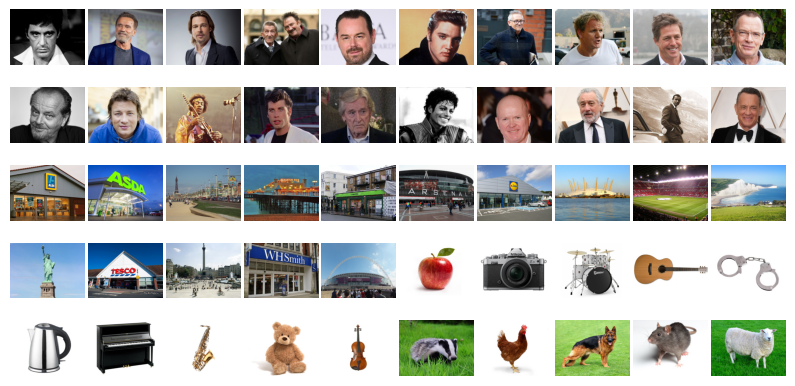

In [ ]:
# Now let's view all the stimuli, which are stored as additional files
# we just load them in and plot them

fig, ax = plt.subplots(5,10,figsize=(10,5), sharex=True, sharey=True, gridspec_kw={'wspace':.05, 'hspace':.05})
for i in np.arange(50):
    plt.sca(ax.flat[i])
    im = np.load(os.path.join(FileDir, Experiment, 'Image%03d.npy'%i))
    plt.imshow(im, cmap='gray',vmin=0,vmax=255)
    plt.axis('off')

Now let's plot rasters for our cells. There are only 6 repeats per stimulus

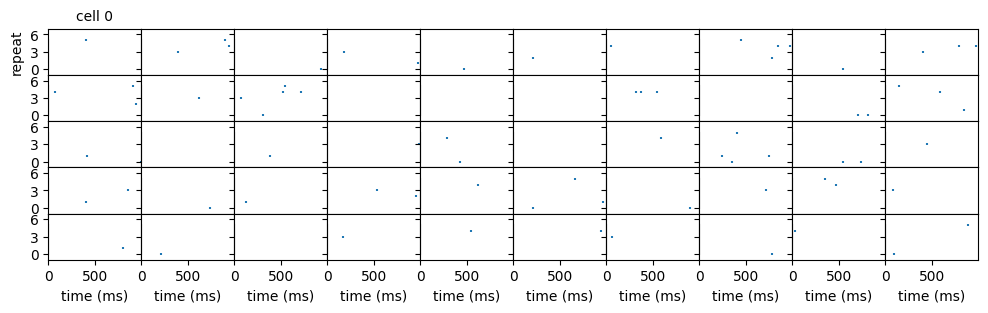

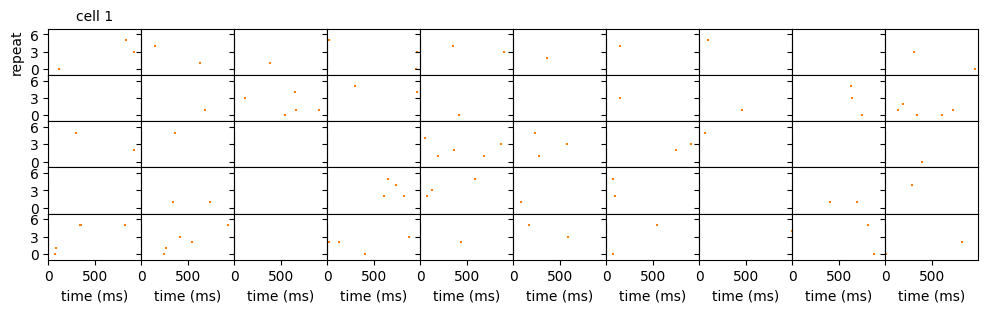

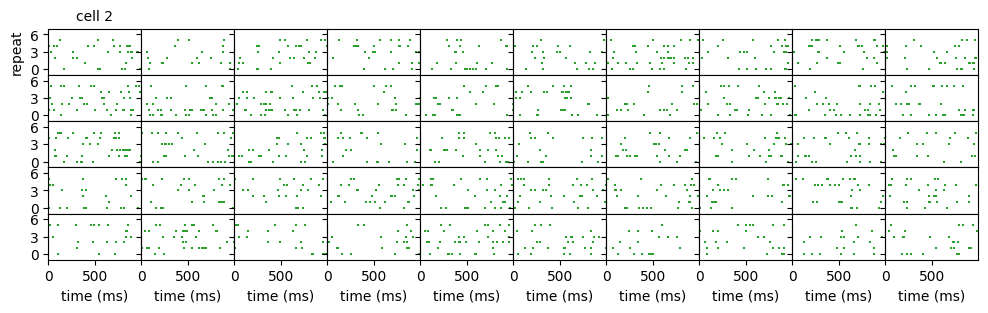

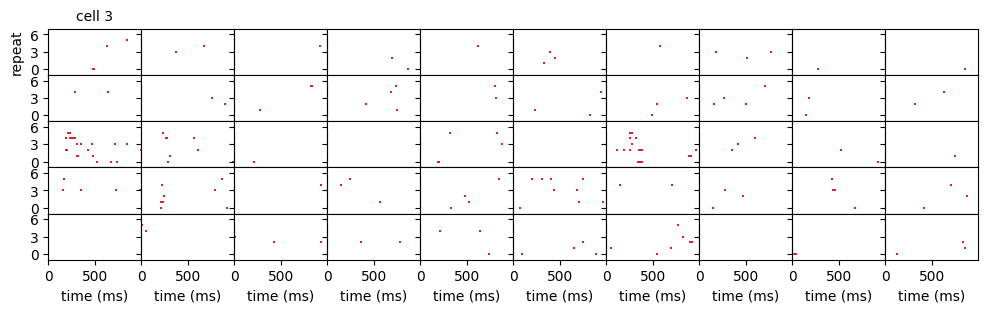

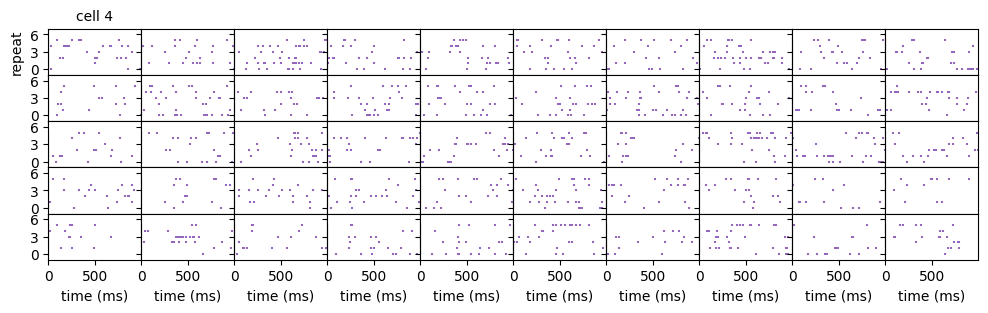

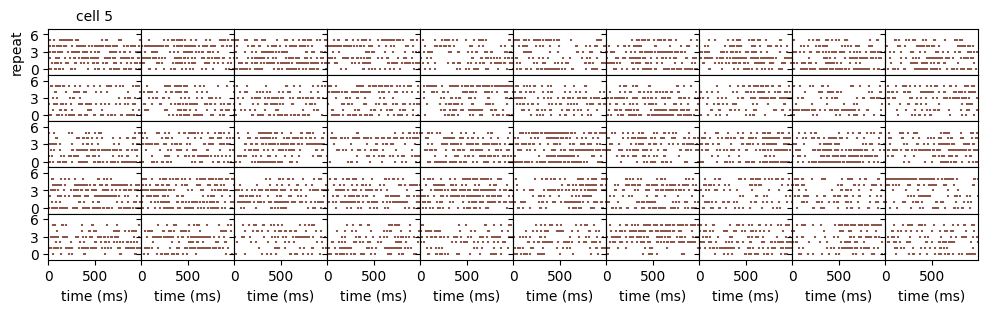

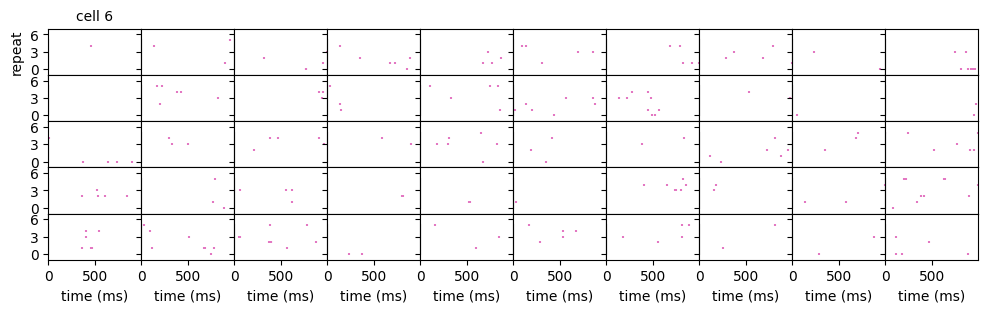

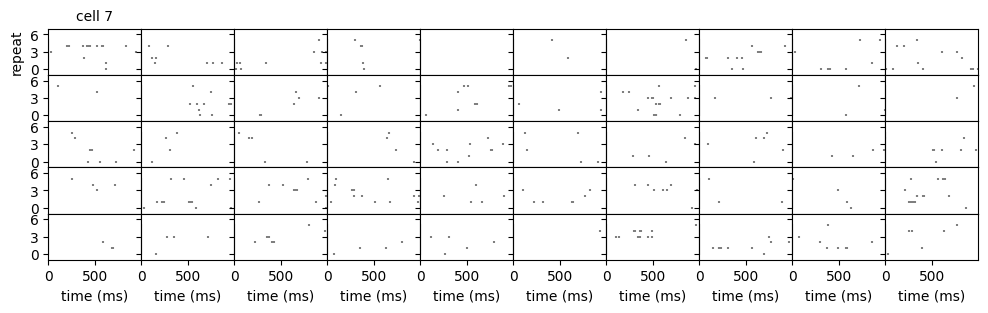

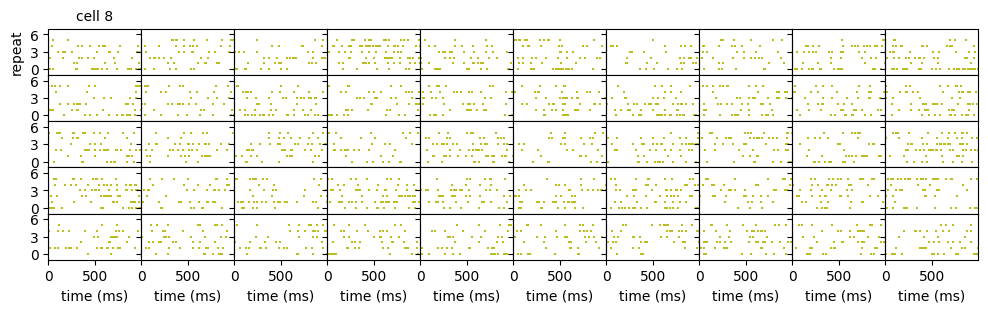

In [ ]:
# first set up arrays saying which cells to view and how to color them
AllCells = np.arange(nClusters)
AllColors = plt.colormaps['tab10'](AllCells)

# now loop over cells making one figure for each
for c, color in zip(AllCells, AllColors):
    fig, ax = plt.subplots(5,10,figsize=(12,3), sharex=True, sharey=True,
                           gridspec_kw={'wspace':.0, 'hspace':.0})


    # now loop over the distinct stimuli (frames) and plot a raster for each
    # the rasters will be plotted in the same order as the images in the cell above
    for i in np.arange(nFrames):

        plt.sca(ax.flat[i])

        # neurocode library has a function to make raster plots
        # to make raster in ms, multiply times by 1000
        nc.plot_raster(spikes.times[spikes.clusters==c]*1000,
                    stims.intervals[stims.frames==i,0]*1000,0,1000,
                   s=1, color=color)

        plt.xticks(np.linspace(0,500,2))
        plt.yticks(np.linspace(0,6,3))
        plt.ylim([-1,7])
        plt.xlabel('time (ms)')
        if i==0: plt.ylabel('repeat'); plt.title('cell %d'%c, fontsize=10)
        plt.gca().label_outer()

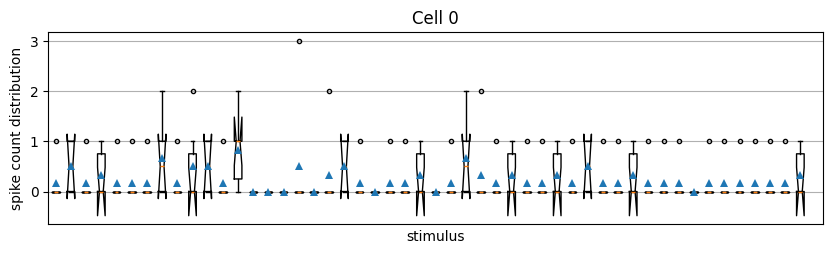

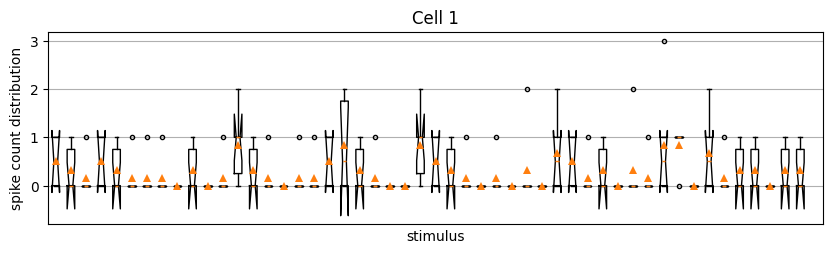

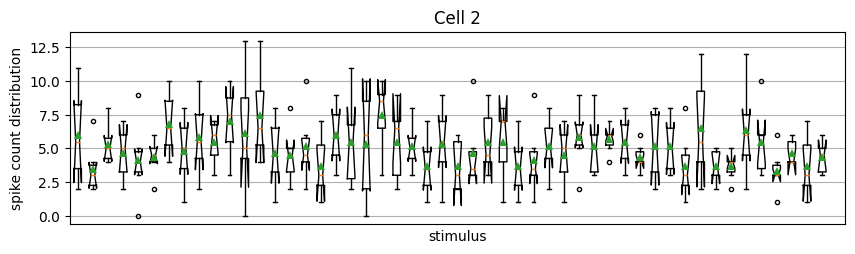

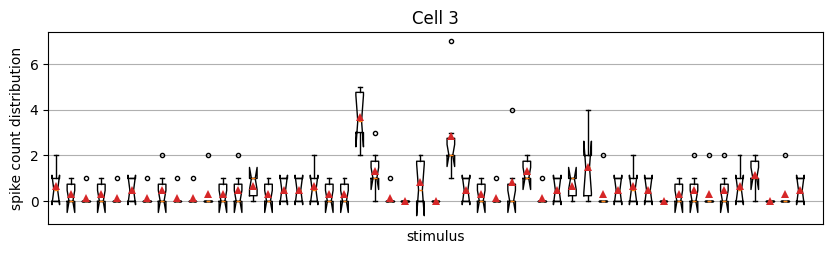

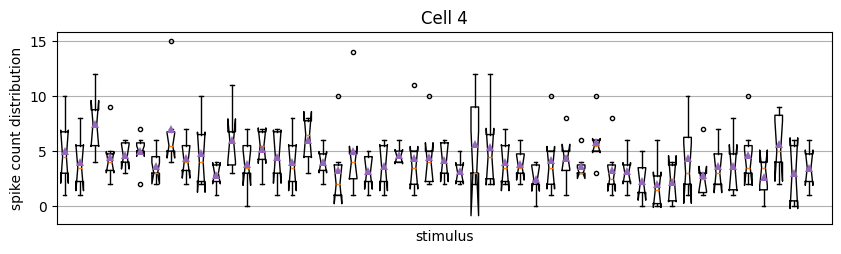

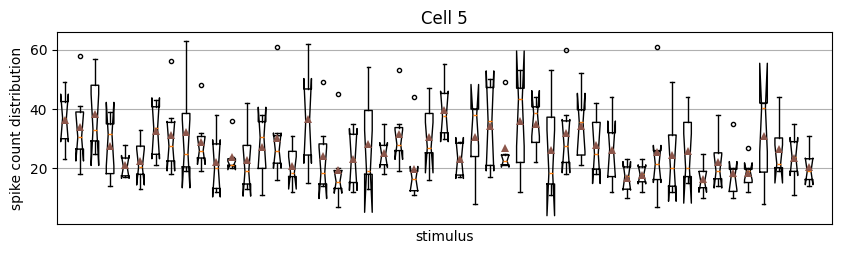

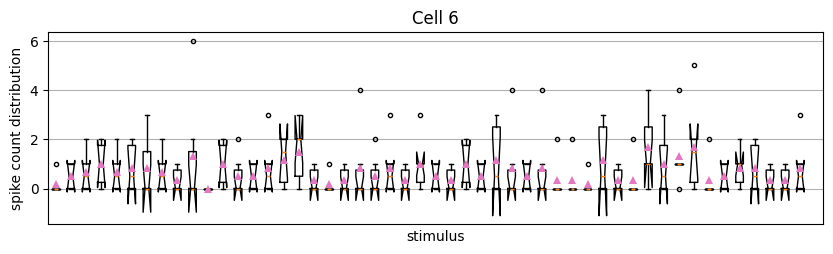

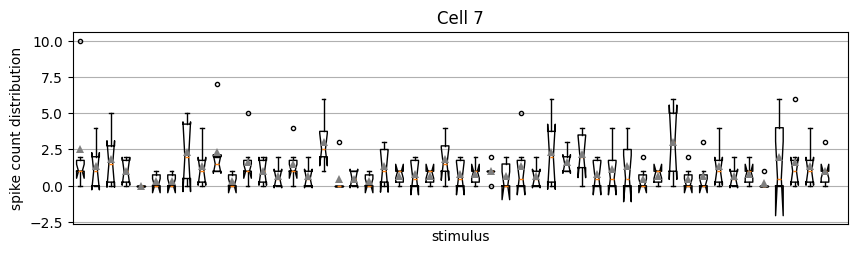

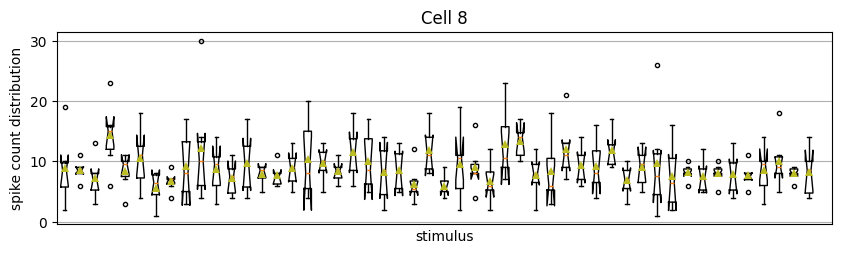

In [ ]:
# now we make box plots for all cells: another way to view the data

for c, color in zip(AllCells, AllColors):
    # make array of spike counts
    my_counts = [stims.spike_counts[stims.frames==i,c] for i in np.arange(nFrames)]

    # box plots
    plt.figure(figsize=[10,2.5])
    plt.boxplot(my_counts, notch=True, sym='.', positions=np.arange(nFrames), showmeans=True,
               meanprops={'markeredgewidth': 0, 'markerfacecolor': color})
    plt.xticks([]);
    plt.xlim(-.5,50.5)

    plt.ylabel('spike count distribution')
    plt.xlabel('stimulus')
    plt.grid(1)
    plt.axis()
    plt.title('Cell %d'%c)

The next set of visualizations are so big that we can't do them for all cells, we need to pick some examples.

EXCERCISE 1: Look at the raster and box plot, and try to guess which cells are going to have statistically significant coding, for which stimuli. Write the cell numbers of the cells you hypothesize in the square brackets below (comma separated) to make a list. (E.g. CellList=[1,2]).  


In [ ]:
# Write your answer here
CellList=[5,8]


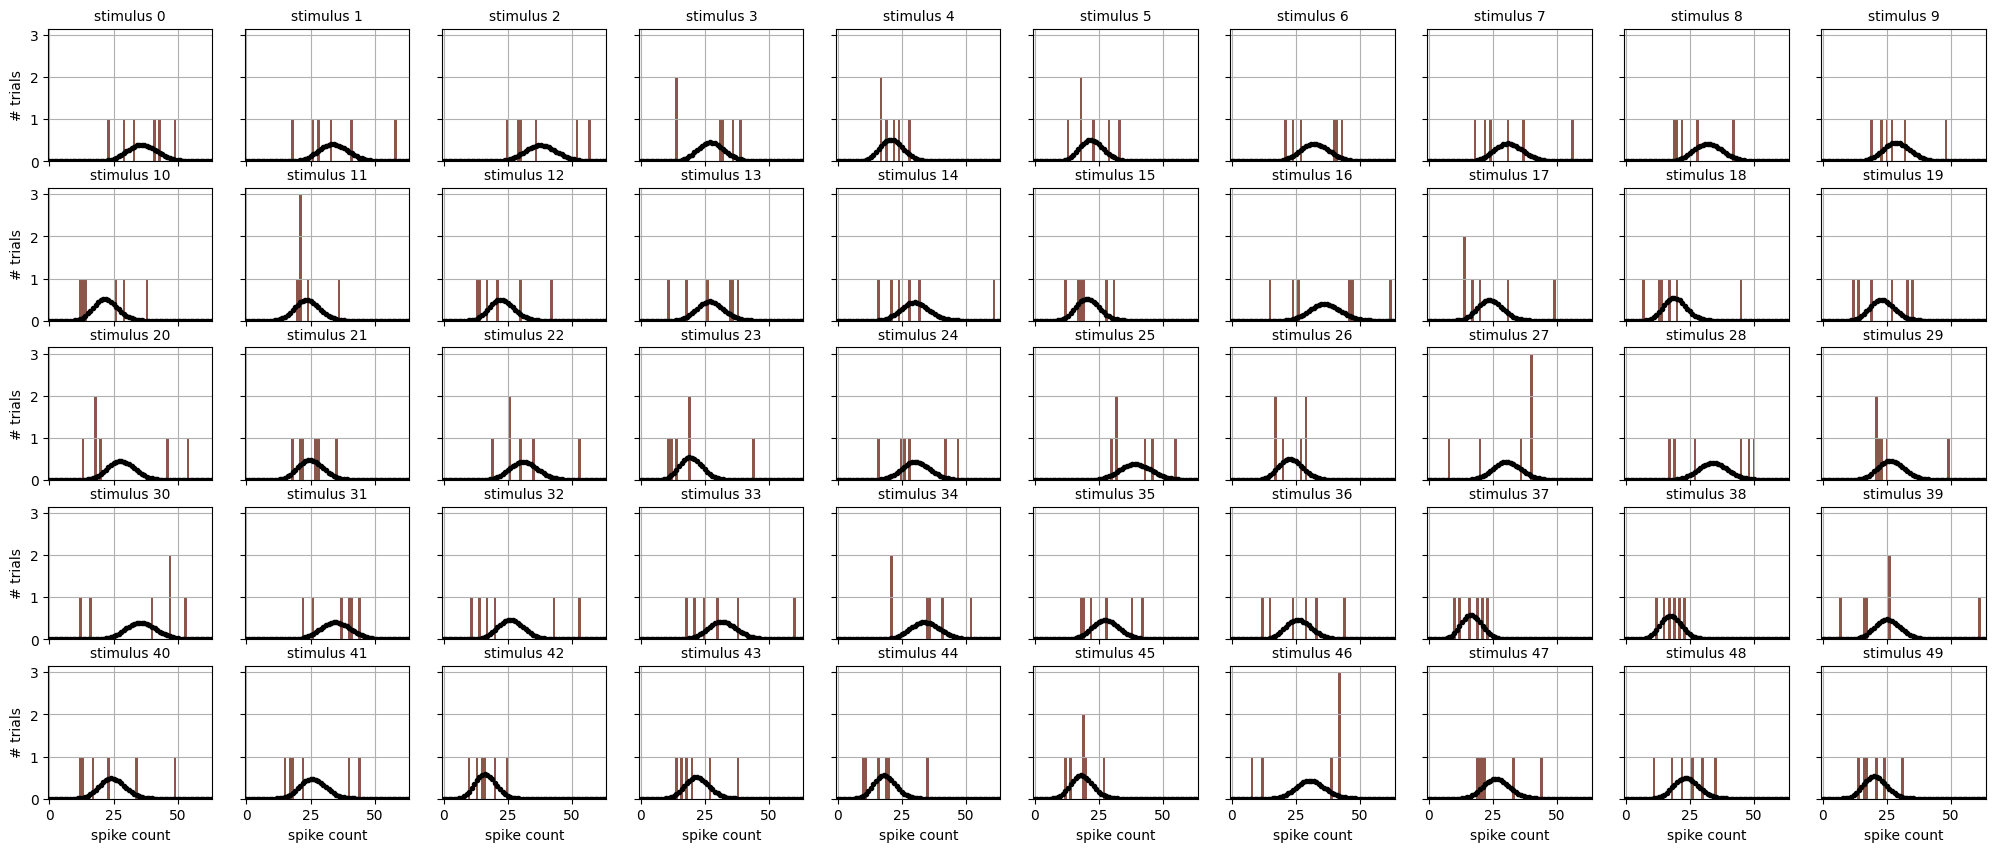

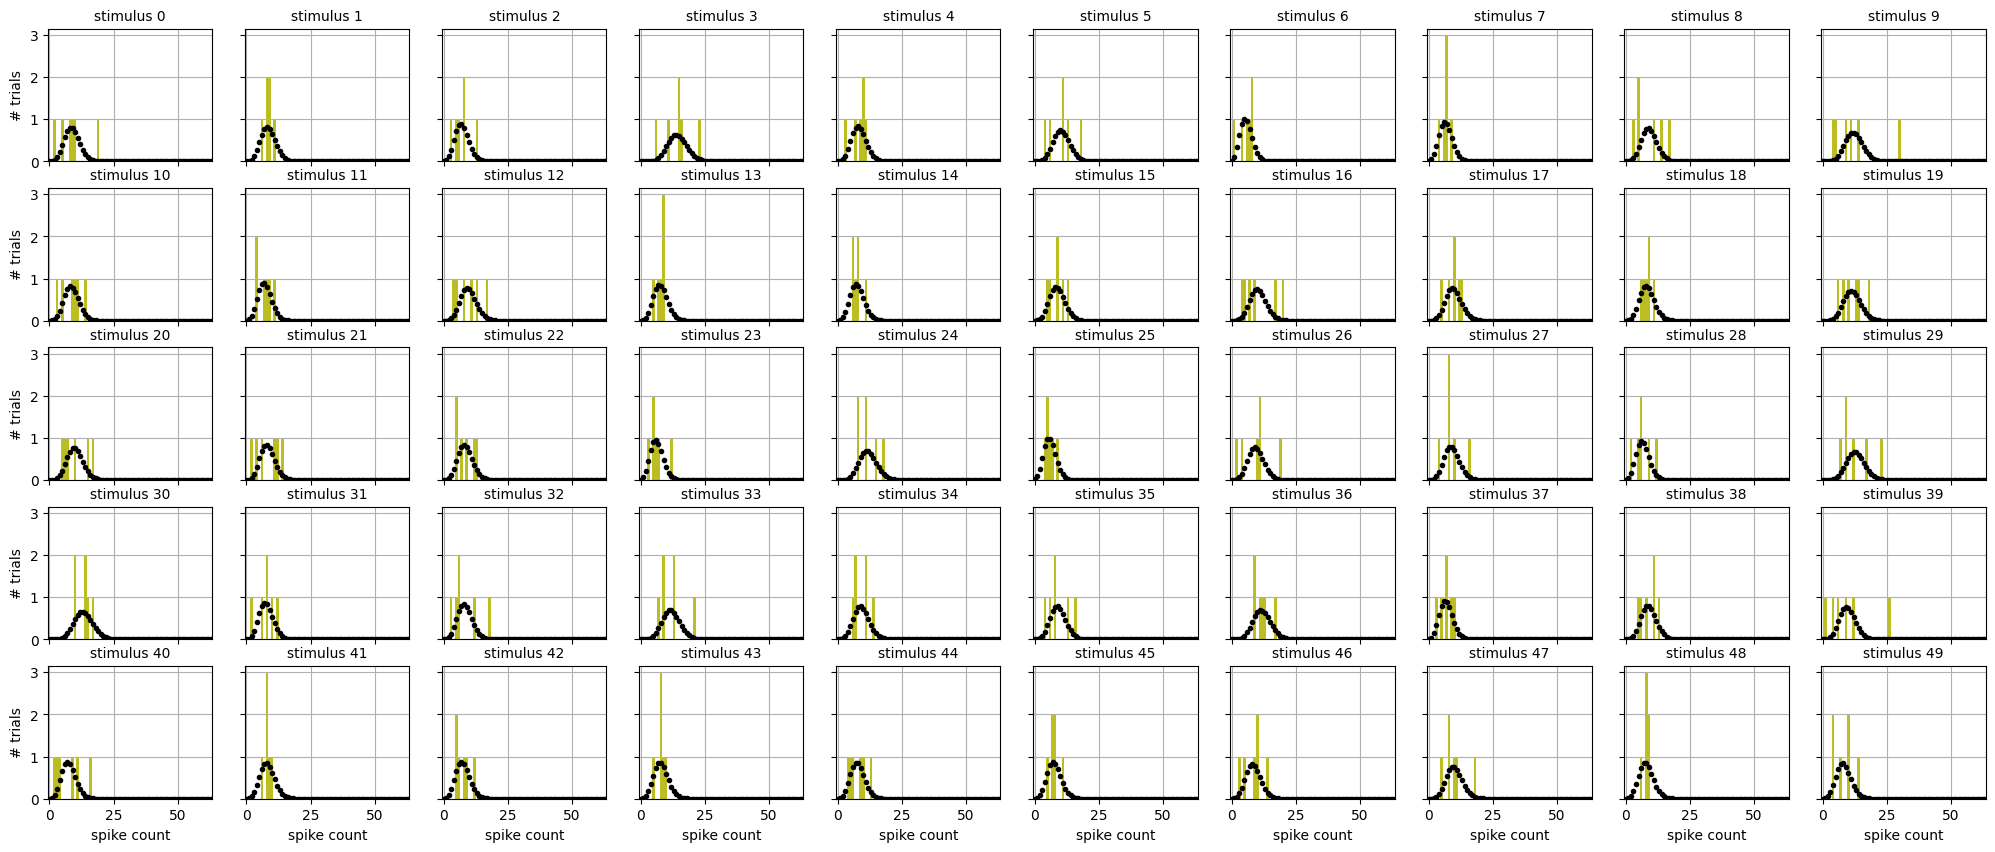

In [ ]:
# now let's look at spike count histograms for the cells,
# and compare them to a Poisson distribution
ExampleCells = np.array(CellList)
ExampleColors = plt.colormaps['tab10'](CellList)

# get max rate for x-axis range
maxRate = stims.spike_counts[:,ExampleCells].max()

for c,color in zip(ExampleCells, ExampleColors):

    fig, ax = plt.subplots(5,10,figsize=(25,10), sharex=True, sharey=True)
    for i in range(nFrames):

      # make array of spike counts for this frame and cell
      my_counts = [stims.spike_counts[stims.frames==i,c] for i in range(nFrames)]

      # plot histogram for this frame
      plt.subplot(5,10,i+1)
      plt.hist(my_counts[i], bins=np.arange(maxRate+1)-.5, color=color)

      plt.title('stimulus %d'%(i), fontsize=10)
      plt.xlim(-.5,maxRate+.5)

      plt.xlabel('spike count')
      plt.ylabel('# trials')
      plt.grid(True)
      xr=np.arange(maxRate+1, dtype=int)
      m = my_counts[i].mean()
      poisson_prob = np.exp(-m)* m**xr / np.array([math.factorial(x) for x in xr])
      plt.plot(xr, poisson_prob*nRepeats, 'k.')
      plt.gca().label_outer()

EXERCISE 2: Did this support your guess to which cells encode which stimuli?

Try again with different example cells

**Write your answer here**

(NOTE: you would not be marked down for guessing wrong here!)

ValueError: num must be an integer with 1 <= num <= 8, not np.int64(9)

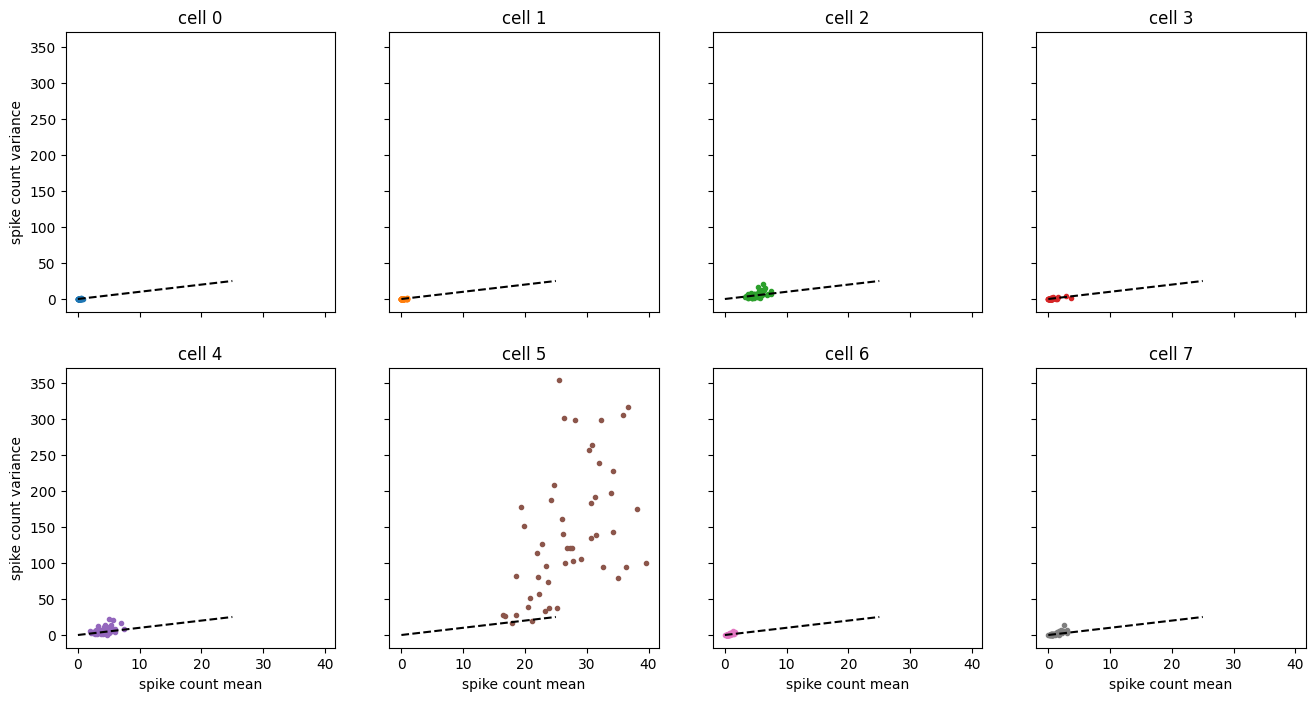

In [ ]:
# now we will compute the mean and variance of spike counts across repeats, for each cell and stimulus.

# first we mean and variance of each cell's responses to each frame
# frames is a bunch, the first dimension of all arrays has size nFrames
frames = nc.Bunch()
frames.mean_rates = np.zeros((nFrames, nClusters))
frames.var_rates = np.zeros((nFrames, nClusters))
frames.n_repeats = np.zeros((nFrames))

for f in np.arange(nFrames):
    my_stims = (stims.frames==f)
    frames.mean_rates[f,:] = stims.spike_counts[my_stims,:].mean(0)
    frames.var_rates[f,:] = stims.spike_counts[my_stims,:].var(0,ddof=1)
    frames.n_repeats[f] = my_stims.sum()

# now plot spike count mean vs. variance over frames for each cell
plt.subplots(2,4,figsize=(16,8),sharex=True, sharey=True)
for c,color,i in zip(AllCells, AllColors,np.arange(nClusters)):
    plt.subplot(2,4,i+1)
    plt.plot(frames.mean_rates[:,c], frames.var_rates[:,c], '.', color=color);

    plt.xlabel('spike count mean')
    plt.ylabel('spike count variance')
    plt.title('cell %d'%c)

    plt.plot([0,25],[0,25],'k--')
    plt.gca().label_outer()

EXERCISE 3: does this look like Poisson distributed?  

To get a better feeling for which cells are Poisson, compute the Fano factor for each cell and stimulus, then make a box plot showing the distribution across stimuli of Fano factors for each cell

HINT: The fano factor is the spike-count variance divided by the spike-count
mean (we have already computed both of these). When you divide them, if the mean is zero you will get nan, which will mess up the plot. So use
np.nan_to_num() to replace any nans in the fano factor with 0.

The Poisson process has a Fano factor of 1. Plot make a horizontal line at 1, by running `plt.axhline(1)`

The answer should look like this:

/tmp/ipython-input-1236541167.py:2: RuntimeWarning: invalid value encountered in divide
  frames.fano_factor = np.nan_to_num(frames.var_rates / frames.mean_rates)


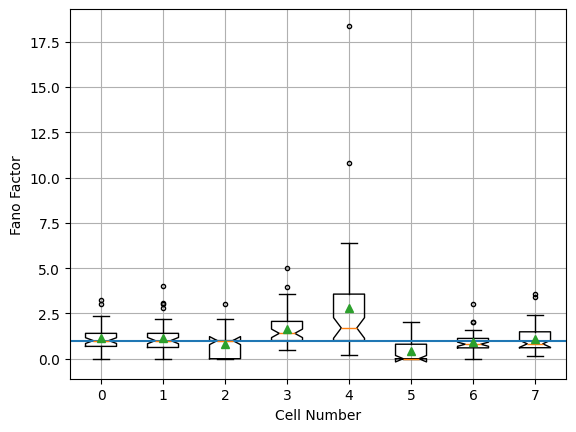

In [ ]:
# Write your answer here
frames.fano_factor = np.nan_to_num(frames.var_rates / frames.mean_rates)

# box plots
plt.boxplot(frames.fano_factor, notch=True, sym='.', positions=np.arange(nClusters), showmeans=True)

plt.ylabel('Fano Factor')
plt.xlabel('Cell Number')
plt.grid(1)
plt.axis()
plt.axhline(1)

cell 0: stimulus-related variance 0.04; p=0.112
cell 1: stimulus-related variance -0.04; p=0.959
cell 2: stimulus-related variance -0.00; p=0.647
cell 3: stimulus-related variance 0.10; p=0.096
cell 4: stimulus-related variance 1.25; p=0.003
cell 5: stimulus-related variance 0.00; p=0.239
cell 6: stimulus-related variance 0.00; p=0.455
cell 7: stimulus-related variance 0.81; p=0.001


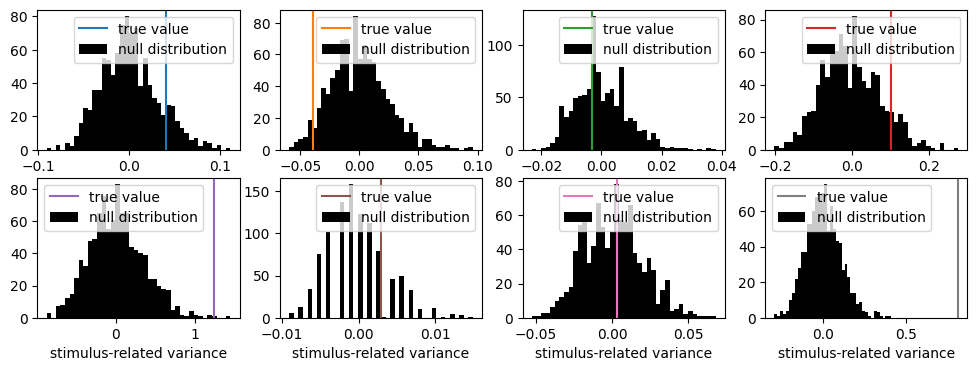

In [ ]:
# now we will do a significance test to see which cells do significantly encode
# these stimuli

plt.subplots(2,4,figsize=[12,4])

for c,color,j in zip(AllCells, AllColors, np.arange(nClusters)):

    # compute the unbiased estimate of stimulus-related variance for this cell
    stim_var = np.var(frames.mean_rates[:,c],ddof=0) \
            - np.mean(frames.var_rates[:,c]/frames.n_repeats)*(nFrames-1)/nFrames


    N=1000
    null = np.zeros(N-1)


    # now make null ensemble
    for i in range(N-1):

        #generate a random permutation
        perm = np.random.permutation(nStims)

        # compute mean and variance of rates for permuted stimuli
        perm_mean_rates = np.zeros((nFrames, nClusters))
        perm_var_rates = np.zeros((nFrames, nClusters))
        perm_n_repeats = np.zeros((nFrames))

        for f in np.arange(nFrames):
          my_stims = (stims.frames[perm]==f)
          perm_mean_rates[f,:] = stims.spike_counts[my_stims,:].mean(0)
          perm_var_rates[f,:] = stims.spike_counts[my_stims,:].var(0,ddof=1)
          perm_n_repeats[f] = my_stims.sum()

        null[i] = np.var(perm_mean_rates[:,c],ddof=0) \
            - np.mean(perm_var_rates[:,c]/perm_n_repeats)*(nFrames-1)/nFrames

    print('cell %d: stimulus-related variance %.2f; p=%.3f'%(c,stim_var, (1+np.sum(null>=stim_var))/1000))

    plt.subplot(2,4,j+1)
    plt.hist(null,40, color='k')
    plt.axvline(stim_var, color=color)
    plt.xlabel('stimulus-related variance')
    plt.legend(('true value', 'null distribution'))

Were you right about the significant cells?  What were the stimuli that drove them?

EXERCISE 4 (OPTIONAL ADVANCED PYTHON): speed up the code in the previous cell by vectorizing the loop over f

EXCERCISE 5: Go back and change Experiment = 'Patient2Session3' to look at another experiment, see whether you have significant cells there, and what they respond to.

HINT: Because there are a different number of cells, and there are figures with one panel per cell, you will need to change the plt.subplots commands to avoid an error